In [1]:
# ============================================================
# PREPROCESSING FILTER:
# Keep only cells that have *ALL* sweeps 10–70 inclusive,
# AND each sweep is long enough for CUT_END (so cropping works).
# Save the kept file paths as a .npy array (no CSV).
# ============================================================

import os, re, h5py
import numpy as np

ROOT_DIR    = "/home/mohammad.shoja/A/dandi_000008"
SWEEP_START = 10
SWEEP_END   = 70
REQ_SWEEPS  = list(range(SWEEP_START, SWEEP_END + 1))

CUT_START   = 2500
CUT_END     = 17500  # must have len >= CUT_END

OUT_NPY     = f"/home/mohammad.shoja/A/{SWEEP_START:03d}_{SWEEP_END:03d}_cut{CUT_START}_{CUT_END}.npy"

# ----------------------------
# Helpers
# ----------------------------
def find_nwb_files(root):
    out = []
    for dirpath, _, filenames in os.walk(root):
        for fn in filenames:
            if fn.endswith(".nwb"):
                out.append(os.path.join(dirpath, fn))
    return sorted(out)

def has_sweep_and_long_enough(f, sidx, cut_end):
    acq = f.get("acquisition", None)
    if acq is None:
        return False, "no_acquisition"
    key = f"CurrentClampSeries{sidx:03d}"
    if key not in acq:
        return False, "missing_sweep"
    vlen = int(acq[key]["data"].shape[0])
    if vlen < cut_end:
        return False, "too_short"
    return True, None

# ----------------------------
# Scan all NWB files
# ----------------------------
nwb_files = find_nwb_files(ROOT_DIR)
print("Found NWB files:", len(nwb_files))
print(f"Required sweeps: {SWEEP_START}–{SWEEP_END} (n={len(REQ_SWEEPS)})")
print(f"Crop window: [{CUT_START}:{CUT_END}] → need each sweep length ≥ {CUT_END}")

kept_paths = []
skip = {"no_acquisition": 0, "missing_sweep": 0, "too_short": 0, "h5_error": 0, "other": 0}

for fp in nwb_files:
    try:
        with h5py.File(fp, "r") as f:
            ok = True
            first_fail_reason = None
            for sidx in REQ_SWEEPS:
                good, reason = has_sweep_and_long_enough(f, sidx, CUT_END)
                if not good:
                    ok = False
                    first_fail_reason = reason
                    break

            if ok:
                kept_paths.append(fp)
            else:
                if first_fail_reason in skip:
                    skip[first_fail_reason] += 1
                else:
                    skip["other"] += 1
    except Exception:
        skip["h5_error"] += 1

# ----------------------------
# Save kept list as .npy
# ----------------------------
kept_paths = np.array(kept_paths)
np.save(OUT_NPY, kept_paths)

print("\n================ SUMMARY ================")
print("Total NWB files scanned:", len(nwb_files))
print("Cells kept (have ALL sweeps 10–70, long enough):", len(kept_paths))
print("\nSkip counts (first failure per file):")
for k, v in skip.items():
    print(f"  {k}: {v}")

print("\n✅ Saved kept file paths to:", OUT_NPY)


Found NWB files: 1328
Required sweeps: 10–70 (n=61)
Crop window: [2500:17500] → need each sweep length ≥ 17500

================ SUMMARY ================
Total NWB files scanned: 1328
Cells kept (have ALL sweeps 10–70, long enough): 1264

Skip counts (first failure per file):
  no_acquisition: 0
  missing_sweep: 64
  too_short: 0
  h5_error: 0
  other: 0

✅ Saved kept file paths to: /home/mohammad.shoja/A/010_070_cut2500_17500.npy


In [2]:
# ============================================================
# STEP 2 (AFTER YOUR FILTER):
# Load kept_paths (.npy)  -> for each kept cell:
#   - crop sweeps 10..70 at [CUT_START:CUT_END]
#   - stack in sweep order => fixed length trace (61 * SEG_LEN)
#   - z-score per cell
#   - compute WST with J=12, Q=20, max_order=2
#   - save ONE NPZ PER CELL with proper identifiers for later joins
# Also:
#   - make WST+trace figures for 9 random cells
# ============================================================

import os, re, random
import numpy as np
import h5py
import matplotlib.pyplot as plt

import torch
from kymatio.torch import Scattering1D

# ----------------------------
# INPUT: the file you already created
# ----------------------------
KEPT_NPY = "/home/mohammad.shoja/A/010_070_cut2500_17500.npy"

# ----------------------------
# CONFIG (must match filter)
# ----------------------------
SWEEP_START = 10
SWEEP_END   = 70
REQ_SWEEPS  = list(range(SWEEP_START, SWEEP_END + 1))
#Chossing the range where the external current is injected
CUT_START = 2500
CUT_END   = 17500
SEG_LEN   = CUT_END - CUT_START

# WST params (could be changes for the different resolution in either time or frequency axis)
J = 12
Q = 20
OVERSAMPLING = 0
MAX_ORDER = 2

# Outputs
OUTDIR = f"/home/mohammad.shoja/A/WST_kept_cells_sweeps{SWEEP_START:03d}_{SWEEP_END:03d}_cut{CUT_START}_{CUT_END}_J{J}_Q{Q}"
PER_CELL_DIR = os.path.join(OUTDIR, "per_cell_npz")
FIG_DIR      = os.path.join(OUTDIR, "figures_random9")

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(PER_CELL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# Random plots
N_RANDOM_PLOTS = 9
RANDOM_SEED = 42

# ----------------------------
# Helpers
# ----------------------------
def file_to_cell_id(fp: str) -> str:
    return os.path.splitext(os.path.basename(fp))[0]

def cell_id_to_short_id(cell_id: str):
    m = re.search(r"ses-(\d+)-sample-(\d+)", str(cell_id))
    return f"{m.group(1)}_sample_{m.group(2)}" if m else None

def safe_name(x: str) -> str:
    return re.sub(r"[^\w\-_\.]+", "_", str(x))

def zscore_1d(x, eps=1e-8):
    x = x.astype(np.float32)
    return (x - x.mean()) / (x.std() + eps)

def save_fig(path, dpi=220):
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close()

def plot_one_cell_bundle(out_subdir, name, stacked, seg_len,
                         S0, S1, S2, xi1_sorted, xi_pairs_sorted, parent_change_rows):
    os.makedirs(out_subdir, exist_ok=True)

    # stacked trace + boundaries
    plt.figure(figsize=(18, 4))
    plt.plot(stacked, lw=0.8)
    for k in range(1, (SWEEP_END - SWEEP_START + 1)):
        plt.axvline(k * seg_len, color="k", alpha=0.15, lw=1)
    plt.title(f"Stacked voltage | {name} | sweeps {SWEEP_START}-{SWEEP_END} | cut[{CUT_START}:{CUT_END}]")
    plt.xlabel("stacked index")
    plt.ylabel("voltage (raw units)")
    save_fig(os.path.join(out_subdir, "01_stacked_trace.png"))

    # S0
    plt.figure(figsize=(10, 2.6))
    plt.plot(S0, lw=1.2)
    plt.title("WST S0")
    plt.xlabel("WST time frames")
    plt.ylabel("S0")
    save_fig(os.path.join(out_subdir, "02_S0.png"))

    # S1 heatmap (y-axis = xi1)
    plt.figure(figsize=(11, 4.5))
    plt.imshow(S1, aspect="auto", origin="upper", cmap="jet")
    ax = plt.gca()
    K = len(xi1_sorted)
    step = max(1, K // 10)
    ticks = np.arange(0, K, step)
    ax.set_yticks(ticks)
    ax.set_yticklabels([f"{xi1_sorted[t]:.3f}" for t in ticks])
    plt.title("WST S1 (sorted by xi1 desc)")
    plt.xlabel("WST time frames")
    plt.ylabel("xi1")
    plt.colorbar()
    save_fig(os.path.join(out_subdir, "03_S1.png"))

    # S2 heatmap (normalize per-parent for visualization)
    S2n = S2.copy()
    start = 0
    for brk in list(parent_change_rows) + [S2n.shape[0]]:
        block = S2n[start:brk]
        d = np.max(block)
        if d > 0:
            S2n[start:brk] = block / d
        start = brk

    plt.figure(figsize=(12, 5.5))
    plt.imshow(S2n, aspect="auto", origin="upper", cmap="jet")
    ax = plt.gca()
    for r in parent_change_rows:
        ax.axhline(y=r - 0.5, color="white", linewidth=0.6, alpha=0.9)

    npaths = S2n.shape[0]
    step2 = max(1, npaths // 12)
    ticks2 = np.arange(0, npaths, step2)
    ax.set_yticks(ticks2)
    ax.set_yticklabels(
        [f"({xi_pairs_sorted[t,0]:.3f},{xi_pairs_sorted[t,1]:.3f})" for t in ticks2],
        fontsize=8
    )
    plt.title("WST S2 (sorted; per-parent normalized for visualization)")
    plt.xlabel("WST time frames")
    plt.ylabel("(xi1, xi2)")
    plt.colorbar()
    save_fig(os.path.join(out_subdir, "04_S2.png"))

# ----------------------------
# Load kept paths
# ----------------------------
kept_paths = np.load(KEPT_NPY, allow_pickle=True)
kept_paths = [str(p) for p in kept_paths]
N = len(kept_paths)
print("✅ Loaded kept cells:", N)

if N == 0:
    raise RuntimeError("kept_paths is empty. Check your filter output file.")

# Fixed stacked length since all sweeps exist for these cells
N_SWEEPS  = len(REQ_SWEEPS)
L_total   = N_SWEEPS * SEG_LEN
print("Sweeps used:", SWEEP_START, "to", SWEEP_END, "| count =", N_SWEEPS)
print("SEG_LEN:", SEG_LEN, "=> stacked length L_total:", L_total)

# ----------------------------
# Build WST object (fixed length!)
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

scattering = Scattering1D(
    J=J, shape=L_total, Q=Q,
    oversampling=OVERSAMPLING,
    max_order=MAX_ORDER
).to(device)

meta = scattering.meta()
order = meta["order"]
xi_all = meta["xi"]

order0 = np.where(order == 0)[0]
order1 = np.where(order == 1)[0]
order2 = np.where(order == 2)[0]

# sort S1 by xi1 desc
xi1 = xi_all[order1, 0]
sort1 = np.argsort(xi1)[::-1]
xi1_sorted = xi1[sort1].astype(np.float32)

# sort S2 by (xi1 desc, xi2 desc)
xi_pairs = xi_all[order2]
perm_S2 = np.lexsort((-xi_pairs[:, 1], -xi_pairs[:, 0]))
xi_pairs_sorted = xi_pairs[perm_S2].astype(np.float32)

parent_change_rows = (np.where(np.diff(xi_pairs_sorted[:, 0]) != 0)[0] + 1).astype(int)

# ----------------------------
# Main loop: crop sweeps, stack, WST, save NPZ
# ----------------------------
saved_npz_paths = []
bad_cells = 0

for i, fp in enumerate(kept_paths):
    cell_id = file_to_cell_id(fp)
    short_id = cell_id_to_short_id(cell_id)
    name = f"{cell_id}__sweeps{SWEEP_START:03d}_{SWEEP_END:03d}__cut{CUT_START}_{CUT_END}"

    try:
        segs = []
        with h5py.File(fp, "r") as f:
            acq = f["acquisition"]
            for sidx in REQ_SWEEPS:
                k = f"CurrentClampSeries{sidx:03d}"
                seg = acq[k]["data"][CUT_START:CUT_END].astype(np.float32)
                # should always be SEG_LEN due to filtering, but keep safe:
                if seg.shape[0] != SEG_LEN:
                    raise RuntimeError(f"Sweep {sidx:03d} seg_len {seg.shape[0]} != {SEG_LEN}")
                segs.append(seg)

        segs = np.stack(segs, axis=0)          # (61, SEG_LEN)
        stacked = segs.reshape(-1)             # (L_total,)
        x = zscore_1d(stacked)                 # z-score per cell

        x_torch = torch.from_numpy(x[None, None, :]).to(device)
        with torch.no_grad():
            Sx = scattering(x_torch).detach().cpu().numpy()

        if Sx.ndim == 4:
            Sx = Sx[:, 0]  # (1,C,T')
        if Sx.shape[1] != len(order):
            Sx = np.transpose(Sx, (0, 2, 1))

        S0 = Sx[:, order0, :]                  # (1,1,T')
        S1_uns = Sx[:, order1, :]
        S2_uns = Sx[:, order2, :]

        S1 = S1_uns[:, sort1, :].astype(np.float32)
        S2 = S2_uns[:, perm_S2, :].astype(np.float32)
        S0 = S0.astype(np.float32)

        out_npz = os.path.join(PER_CELL_DIR, f"{safe_name(name)}__WST.npz")
        np.savez_compressed(
            out_npz,
            name=np.array([name]),
            cell_id=np.array([cell_id]),
            short_id=np.array([short_id if short_id is not None else ""]),
            file_path=np.array([fp]),

            sweeps_used=np.array(REQ_SWEEPS, dtype=int),
            cut=np.array([CUT_START, CUT_END], dtype=int),
            seg_len=np.array([SEG_LEN], dtype=int),
            stacked_len=np.array([L_total], dtype=int),

            stacked_trace=stacked.astype(np.float32),  # raw stacked trace

            S0=S0[0],   # (1,T')
            S1=S1[0],   # (n1,T')
            S2=S2[0],   # (n2,T')

            xi1=xi1_sorted,
            xi_pairs=xi_pairs_sorted,
            parent_change_rows=parent_change_rows,

            # params
            J=np.array([J], dtype=int),
            Q=np.array([Q], dtype=int),
            oversampling=np.array([OVERSAMPLING], dtype=int),
            max_order=np.array([MAX_ORDER], dtype=int),
        )

        saved_npz_paths.append(out_npz)

    except Exception as e:
        bad_cells += 1
        if bad_cells <= 10:
            print("⚠️ Failed:", fp, "|", repr(e))
        continue

    if (i + 1) % 50 == 0 or (i + 1) == N:
        print(f"Processed {i+1}/{N} (saved {len(saved_npz_paths)} NPZ, failed {bad_cells})")

print("\n✅ Done WST for kept cells.")
print("Saved NPZ:", len(saved_npz_paths))
print("Failed:", bad_cells)
print("OUTDIR:", OUTDIR)
print("NPZ folder:", PER_CELL_DIR)

# ----------------------------
# Plot 9 random cells
# ----------------------------
if len(saved_npz_paths) > 0:
    random.seed(RANDOM_SEED)
    pick = random.sample(saved_npz_paths, k=min(N_RANDOM_PLOTS, len(saved_npz_paths)))

    for j, npz_path in enumerate(pick, 1):
        z = np.load(npz_path, allow_pickle=True)

        name = str(z["name"][0])
        stacked = z["stacked_trace"]
        S0 = z["S0"][0] if z["S0"].ndim == 2 else z["S0"]
        S1 = z["S1"]
        S2 = z["S2"]
        xi1_s = z["xi1"]
        xi_pairs_s = z["xi_pairs"]
        pcr = z["parent_change_rows"]

        out_subdir = os.path.join(FIG_DIR, f"{j:02d}__{safe_name(name)}")
        plot_one_cell_bundle(out_subdir, name, stacked, SEG_LEN,
                             S0, S1, S2, xi1_s, xi_pairs_s, pcr)

    print("\n✅ Saved random-9 figures to:", FIG_DIR)
else:
    print("\n⚠️ No NPZ files saved; skipping random-9 plots.")


✅ Loaded kept cells: 1264
Sweeps used: 10 to 70 | count = 61
SEG_LEN: 15000 => stacked length L_total: 915000
Device: cuda
Processed 50/1264 (saved 50 NPZ, failed 0)
Processed 100/1264 (saved 100 NPZ, failed 0)
Processed 150/1264 (saved 150 NPZ, failed 0)
Processed 200/1264 (saved 200 NPZ, failed 0)
Processed 250/1264 (saved 250 NPZ, failed 0)
Processed 300/1264 (saved 300 NPZ, failed 0)
Processed 350/1264 (saved 350 NPZ, failed 0)
Processed 400/1264 (saved 400 NPZ, failed 0)
Processed 450/1264 (saved 450 NPZ, failed 0)
Processed 500/1264 (saved 500 NPZ, failed 0)
Processed 550/1264 (saved 550 NPZ, failed 0)
Processed 600/1264 (saved 600 NPZ, failed 0)
Processed 650/1264 (saved 650 NPZ, failed 0)
Processed 700/1264 (saved 700 NPZ, failed 0)
Processed 750/1264 (saved 750 NPZ, failed 0)
Processed 800/1264 (saved 800 NPZ, failed 0)
Processed 850/1264 (saved 850 NPZ, failed 0)
Processed 900/1264 (saved 900 NPZ, failed 0)
Processed 950/1264 (saved 950 NPZ, failed 0)
Processed 1000/1264 (sav

DISTANCE MEASUREMENT ON TWO FEATURE SPACE

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
ONE CELL MASTER (Merged Sweeps WST) 

What this script does (high-level):
1) Index all per-cell WST NPZ files and map each NPZ -> a unified cell key (short_id).
2) Load EPHYS features CSV and create the same unified short_id key for each row.
3) (Optional) Load metadata and exclude "low quality" RNA families.
4) Keep only cells present in BOTH WST (NPZ) and EPHYS (CSV).
5) Drop cells with NaNs in numeric EPHYS features (distances must be computable).
6) Load WST arrays (S1, S2, stacked_trace) for remaining cells.
   - (Optional) drop obvious artifact/corrupted traces BEFORE distances.
   - Verify the wavelet bank (xi1, xi_pairs) is identical across NPZ files.
7) Build feature matrices:
   - X_wst = flatten(S1) + flatten(S2)  (RAW features; no z-scoring before pdist)
   - X_ephys = numeric columns from EPHYS CSV  (RAW features; no z-scoring before pdist)
   - Optionally create X_ephys_z for interpretability in plots/report only.
8) Compute pairwise distances using pdist(metric="cosine") for both WST and EPHYS.
9) Select one pair in each "quadrant" (LL, LH, HL, HH, MID) on the dx vs dy scatter.
10) For each selected pair, save:
    - scatter plot with circled selected pair
    - stacked trace plot (overlay)
    - WST S1/S2 plots (heatmaps) + labels
    - EPHYS barplot (z-scored only for readability, distances still RAW)
    - a text report (includes RNA family annotations when metadata is available)

NOTE:
- Distances are computed on RAW features.
- Any StandardScaler is used ONLY for report/plots (interpretability).
"""

import os
import re
import glob
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform


# ======================================================================================
# 0) PATHS
# ======================================================================================

PER_CELL_NPZ_DIR = "/home/mohammad.shoja/A/WST_kept_cells_sweeps010_070_cut2500_17500_J12_Q20/per_cell_npz"
EPHYS_CSV        = "/home/mohammad.shoja/A/m1_patchseq_ephys_features.csv"
META_CSV         = "/home/mohammad.shoja/A/m1_patchseq_meta_data.csv"

OUTDIR = "/home/mohammad.shoja/A/ONECELL_MASTER_MERGEDSWEEPS__READABLE__ARTIFACT_SAFE__RAW_COSINE__ALL_BEST"
os.makedirs(OUTDIR, exist_ok=True)


# ======================================================================================
# 1) SETTINGS
# ======================================================================================

# Distances
METRIC = "cosine"     # used for BOTH WST and EPHYS distances (dx_wst, dy_ephys)

# Scatter plot sampling
MAX_SCATTER_POINTS = None   # None => plot ALL pairs (can be huge)
RNG_SEED = 0

# Duplicate detection: if both dx and dy are ~0, treat that as a duplicated pair and skip when selecting
DUP_EPS = 1e-6

# EPHYS z-score:
# - Not used for distance computation.
# - Only used to make barplots/report easier to interpret.
MAKE_EPHYS_Z_FOR_REPORT = True
CLOSE_DZ = 0.25
VERY_DIFF_DZ = 1.0

# Quadrant selection rank:
# 0 = best candidate, 1 = second-best candidate, ...
QUADRANT_PICK_RANK = {"LL": 0, "LH": 0, "HL": 0, "HH": 0, "MID": 0}

# Plot style
POINT_SIZE  = 1
POINT_ALPHA = 0.06
BAR_ALPHA   = 0.55
BAR_WIDTH   = 0.42

# Trace equality check (for debugging)
TRACE_ALLCLOSE_RTOL = 1e-6
TRACE_ALLCLOSE_ATOL = 1e-8

# WST plot labeling density
S1_YTICKS_TARGET = 10
S2_YTICKS_TARGET = 15
LABEL_DECIMALS_XI  = 3
LABEL_DECIMALS_PCT = 1

# For "contribution%" and mean-frequency scalar
USE_ABS_FOR_CONTRIB = True
USE_ABS_FOR_MEANFREQ = True

# Metadata filtering
EXCLUDE_LOW_QUALITY_FAMILY = True
BAD_FAMILY_LABELS = {"low quality", "low_quality", "low-quality", "lowquality"}

# Artifact trace filtering
ARTIFACT_FILTER_ENABLED = True
TRACE_MAX_ABS_THRESHOLD   = 300.0   # catches clipped junk (e.g. ±1000)
TRACE_FLAT_FRAC_THRESHOLD = 0.20    # catches long plateaus/padding
TRACE_VAR_THRESHOLD       = 1e5     # catches crazy variance


# ======================================================================================
# 2) ID MAPPING HELPERS (make all sources agree on ONE key: short_id = "YYYYMMDD_sample_X")
# ======================================================================================

def ephys_to_short_id(cell_id_str: str):
    """
    EPHYS has a column "cell id". Convert it to the unified key:
      "YYYYMMDD_sample_X"
    by extracting: digits + "_sample_" + digits.
    """
    s = str(cell_id_str).strip()
    m = re.search(r"(\d+)_sample_(\d+)", s)
    if m:
        return f"{m.group(1)}_sample_{m.group(2)}"
    return None


def meta_to_short_id(cell_str: str):
    """
    Metadata "Cell" can appear in multiple formats. Normalize it into:
      "YYYYMMDD_sample_X"

    Supported patterns:
      - ses-YYYYMMDD-sample-X
      - YYYYMMDD_sample_X
      - YYYYMMDD ... sample[_-]X   (looser fallback)
    """
    s = str(cell_str).strip()

    m = re.search(r"ses-(\d{8})-sample-(\d+)", s)
    if m:
        return f"{m.group(1)}_sample_{m.group(2)}"

    m = re.search(r"(\d{8})_sample_(\d+)", s)
    if m:
        return f"{m.group(1)}_sample_{m.group(2)}"

    m = re.search(r"(\d{8}).*sample[_-](\d+)", s)
    if m:
        return f"{m.group(1)}_sample_{m.group(2)}"

    # If parsing fails, return the raw string (keeps pipeline from crashing).
    return s


def npz_filename_to_short_id(npz_path: str):
    """
    Per-cell NPZ filenames typically contain:
      "ses-YYYYMMDD-sample-X"
    Extract that and convert to "YYYYMMDD_sample_X".
    """
    base = os.path.basename(npz_path)
    m = re.search(r"ses-(\d+)-sample-(\d+)", base)
    if m:
        return f"{m.group(1)}_sample_{m.group(2)}"
    return None


# ======================================================================================
# 3) TRACE ARTIFACT FILTER
# ======================================================================================

def is_bad_trace(stacked_trace,
                 max_abs_threshold=TRACE_MAX_ABS_THRESHOLD,
                 flat_frac_threshold=TRACE_FLAT_FRAC_THRESHOLD,
                 var_threshold=TRACE_VAR_THRESHOLD):
    """
    Detect obviously corrupted/saturated traces.
    Return True if it looks bad.

    Heuristics:
      1) Too short -> bad
      2) Max abs too large -> clipping/junk
      3) Variance too high -> corrupted
      4) Too flat for too long -> padding/saturation
    """
    x = np.asarray(stacked_trace)
    if x.size < 10:
        return True

    if np.max(np.abs(x)) > max_abs_threshold:
        return True

    if np.var(x) > var_threshold:
        return True

    dx = np.diff(x)
    flat_frac = np.mean(np.abs(dx) < 1e-6)
    if flat_frac > flat_frac_threshold:
        return True

    return False


# ======================================================================================
# 4) META LOADING (optional; used only to filter RNA-family and annotate report)
# ======================================================================================

def read_csv_robust(path: str) -> pd.DataFrame:
    """
    Try to read a CSV/TSV-like file with unknown delimiter robustly.
    """
    with open(path, "r", encoding="utf-8-sig", errors="replace") as f:
        sample = f.read(120_000)

    candidates = [",", "\t", ";", "|"]
    try:
        dialect = csv.Sniffer().sniff(sample, delimiters=candidates)
        sep = dialect.delimiter
    except Exception:
        header = next((ln for ln in sample.splitlines() if ln.strip()), sample)
        sep = max(candidates, key=lambda d: header.count(d))

    attempts = [
        dict(sep=sep, engine="python"),
        dict(sep=sep, engine="python", quotechar='"'),
        dict(sep=sep, engine="python", quotechar="'"),
        dict(sep=None, engine="python"),  # pandas tries to infer
    ]

    last_err = None
    for kw in attempts:
        try:
            df = pd.read_csv(path, encoding="utf-8-sig", on_bad_lines="skip", **kw)
            if df.shape[1] >= 2:
                print(f"[CSV] read_csv success with kwargs={kw} | shape={df.shape}")
                return df
        except Exception as e:
            last_err = e

    raise RuntimeError(f"Could not parse file: {path}. Last error: {last_err}")


def is_bad_family_label(fam: str) -> bool:
    if fam is None:
        return True
    f = str(fam).strip().lower()
    f = re.sub(r"\s+", " ", f)
    return f in BAD_FAMILY_LABELS


def load_metadata_maps(meta_path: str):
    """
    Returns:
      meta_map_family: short_id -> RNA family
      meta_map_name:   short_id -> raw metadata 'Cell' name
    """
    meta_map_family = {}
    meta_map_name = {}

    try:
        meta = read_csv_robust(meta_path)

        if "Cell" not in meta.columns:
            raise ValueError(f"[META] Column 'Cell' not found. Columns are: {list(meta.columns)}")
        if "RNA family" not in meta.columns:
            raise ValueError(f"[META] Column 'RNA family' not found. Columns are: {list(meta.columns)}")

        meta["Cell_raw"] = meta["Cell"].astype(str).str.strip()
        meta["short_id"] = meta["Cell_raw"].apply(meta_to_short_id)

        meta_map_family = dict(zip(meta["short_id"].values, meta["RNA family"].astype(str).values))
        meta_map_name   = dict(zip(meta["short_id"].values, meta["Cell_raw"].values))
        print("[META] Loaded OK:", meta.shape)

    except Exception as e:
        print("[META] Not loaded (continuing without RNA family). Error:", e)

    return meta_map_family, meta_map_name


def get_meta(meta_map_family, meta_map_name, short_id):
    raw = meta_map_name.get(short_id, short_id)
    fam = meta_map_family.get(short_id, "NA")
    return raw, fam


# ======================================================================================
# 5) LOAD + INDEX WST NPZ FILES
# ======================================================================================

def build_npz_index(npz_dir: str):
    """
    Build a dictionary:
      npz_map[short_id] = path_to_npz
    """
    npz_paths = sorted(glob.glob(os.path.join(npz_dir, "*.npz")))
    if len(npz_paths) == 0:
        raise RuntimeError(f"No NPZ files found in: {npz_dir}")

    npz_map = {}
    for p in npz_paths:
        sid = npz_filename_to_short_id(p)
        if sid is None:
            continue
        # keep first occurrence if duplicates exist
        if sid not in npz_map:
            npz_map[sid] = p

    wst_ids = np.array(sorted(npz_map.keys()), dtype=object)
    print("[WST] per-cell NPZ files:", len(npz_paths), "| unique short_id:", len(wst_ids))
    return npz_map, wst_ids


# ======================================================================================
# 6) LOAD EPHYS AND PREPARE NUMERIC MATRIX
# ======================================================================================

def load_ephys_table(ephys_csv: str):
    ephys = pd.read_csv(ephys_csv)
    if "cell id" not in ephys.columns:
        raise ValueError("EPHYS file must contain column 'cell id'")

    ephys["short_id"] = ephys["cell id"].astype(str).map(ephys_to_short_id)
    ephys = ephys.dropna(subset=["short_id"]).drop_duplicates("short_id", keep="first").reset_index(drop=True)
    print("[EPHYS] unique short_id:", len(ephys))
    return ephys


def drop_ephys_nans_and_align(common_ids: np.ndarray, ephys: pd.DataFrame):
    """
    Given common_ids (short_id list), align EPHYS rows to that order and drop any row that has NaNs.
    Returns:
      common_ids_clean, X_ephys_df_clean
    """
    row_map = dict(zip(ephys["short_id"].values, ephys.index.values))
    idx = np.array([row_map[c] for c in common_ids], dtype=int)
    ephys_sel = ephys.loc[idx].copy()

    X_ephys_df = ephys_sel.select_dtypes(include=[np.number]).copy()
    good = ~X_ephys_df.isna().any(axis=1).values

    print("[EPHYS] Rows with any NaN in numeric features:", (~good).sum())
    common_ids2 = common_ids[good]
    X_ephys_df2 = X_ephys_df.loc[good].reset_index(drop=True)

    print("[MATCH] After NaN filtering:", len(common_ids2), "| EPHYS dims:", X_ephys_df2.shape[1])
    return common_ids2, X_ephys_df2


# ======================================================================================
# 7) LOAD WST FROM NPZ (S1,S2,trace) AND APPLY ARTIFACT FILTER
# ======================================================================================

def load_wst_for_ids(common_ids: np.ndarray, npz_map: dict):
    """
    For each short_id in common_ids:
      - read NPZ
      - get S1, S2, stacked_trace
      - (optional) filter artifact traces
      - verify xi1 and xi_pairs are identical across all kept cells

    Returns:
      kept_ids (np.array of short_id)
      S1_sel (N, n1, T')
      S2_sel (N, n2, T')
      stacked_traces (list length N)
      xi1_ref (n1,)
      xi_pairs_ref (n2,2)
    """
    kept_ids = []
    S1_list, S2_list, stacked_list = [], [], []
    xi1_ref = None
    xi_pairs_ref = None

    failed = 0
    dropped_artifact = 0

    for sid in common_ids:
        p = npz_map.get(sid, None)
        if p is None:
            failed += 1
            continue

        try:
            z = np.load(p, allow_pickle=True)

            S1 = z["S1"].astype(np.float32)
            S2 = z["S2"].astype(np.float32)
            stacked = z["stacked_trace"].astype(np.float32)

            if ARTIFACT_FILTER_ENABLED and is_bad_trace(stacked):
                dropped_artifact += 1
                continue

            xi1 = z["xi1"].astype(np.float32)
            xi_pairs = z["xi_pairs"].astype(np.float32)

            # wavelet bank consistency check
            if xi1_ref is None:
                xi1_ref = xi1.copy()
            else:
                if xi1.shape != xi1_ref.shape or np.max(np.abs(xi1 - xi1_ref)) > 1e-7:
                    raise RuntimeError("xi1 differs between NPZ files; expected identical wavelet bank.")

            if xi_pairs_ref is None:
                xi_pairs_ref = xi_pairs.copy()
            else:
                if xi_pairs.shape != xi_pairs_ref.shape or np.max(np.abs(xi_pairs - xi_pairs_ref)) > 1e-7:
                    raise RuntimeError("xi_pairs differs between NPZ files; expected identical wavelet bank.")

            kept_ids.append(sid)
            S1_list.append(S1)
            S2_list.append(S2)
            stacked_list.append(stacked)

        except Exception as e:
            failed += 1
            if failed <= 5:
                print("[WST] Failed to read:", p, "|", repr(e))

    print(f"[WST] Loaded WST for {len(kept_ids)}/{len(common_ids)} common cells (failed {failed})")
    print(f"[FILTER] Dropped artifact traces: {dropped_artifact}")

    if len(kept_ids) < 3:
        raise RuntimeError("Too few WST-loaded common cells after artifact filtering.")

    kept_ids = np.array(kept_ids, dtype=object)
    S1_sel = np.stack(S1_list, axis=0)
    S2_sel = np.stack(S2_list, axis=0)

    print("[WST] S1 shape:", S1_sel.shape, "| S2 shape:", S2_sel.shape, "| N cells:", len(kept_ids))
    return kept_ids, S1_sel, S2_sel, stacked_list, xi1_ref, xi_pairs_ref


# ======================================================================================
# 8) DISTANCE + QUADRANT SELECTION HELPERS
# ======================================================================================

def condensed_idx_to_pair(best_idx: int, n_cells: int):
    """
    Convert condensed pdist index -> (i,j)
    """
    tmp = np.zeros((n_cells * (n_cells - 1)) // 2, dtype=np.int8)
    tmp[best_idx] = 1
    M = squareform(tmp)
    i, j = np.argwhere(M == 1)[0]
    return int(i), int(j)


def sample_for_scatter(x, y, max_points, seed=0):
    """
    Optionally subsample scatter for speed.
    """
    if max_points is None:
        return x, y, None
    if len(x) <= max_points:
        return x, y, None
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(x), size=max_points, replace=False)
    return x[idx], y[idx], idx


def select_from_candidates(cand, score, pick_rank=0, dx=None, dy=None):
    """
    cand: array of indices into the condensed distance arrays
    score: same length as cand (higher score = better)
    pick_rank: 0 best, 1 second best, ...

    Skip near-duplicate pairs (dx~0 and dy~0) if dx/dy passed.
    """
    if len(cand) == 0:
        return None

    order = np.argsort(score)[::-1]  # descending
    r0 = min(max(pick_rank, 0), len(order) - 1)

    for rr in range(r0, min(len(order), r0 + 30)):
        idx = cand[order[rr]]
        if dx is not None and dy is not None:
            if (dx[idx] < DUP_EPS) and (dy[idx] < DUP_EPS):
                continue
        return idx

    return cand[order[0]]


def find_pair_quadrant(dx, dy, quadrant, base_q=0.01):
    """
    Choose a pair index (in condensed form) from a region of the dx vs dy scatter.

    Quadrants:
      LL: dx low, dy low  -> smallest dx+dy
      LH: dx low, dy high -> largest dy
      HL: dx high, dy low -> largest dx
      HH: dx high, dy high-> largest (dx+dy)
      MID: closest to the median center

    Start with strict quantiles and relax until candidates exist.
    """
    pick_rank = QUADRANT_PICK_RANK.get(quadrant, 0)

    if quadrant == "MID":
        cx = np.median(dx)
        cy = np.median(dy)
        dist2 = (dx - cx) ** 2 + (dy - cy) ** 2
        order = np.argsort(dist2)
        for idx in order:
            if not (dx[idx] < DUP_EPS and dy[idx] < DUP_EPS):
                return idx, "median-center"
        raise RuntimeError("All candidates near center looked like duplicates.")

    qs = [0.001, 0.002, 0.005, base_q, 0.02, 0.05, 0.1, 0.2]
    for q in qs:
        w_low  = np.quantile(dx, q)
        w_high = np.quantile(dx, 1 - q)
        e_low  = np.quantile(dy, q)
        e_high = np.quantile(dy, 1 - q)

        if quadrant == "LL":
            mask = (dx <= w_low) & (dy <= e_low)
            cand = np.where(mask)[0]
            if len(cand) > 0:
                score = -(dx[cand] + dy[cand])  # smallest dx+dy
                idx = select_from_candidates(cand, score, pick_rank=pick_rank, dx=dx, dy=dy)
                return idx, q

        if quadrant == "LH":
            mask = (dx <= w_low) & (dy >= e_high)
            cand = np.where(mask)[0]
            if len(cand) > 0:
                score = dy[cand]  # largest dy
                idx = select_from_candidates(cand, score, pick_rank=pick_rank, dx=dx, dy=dy)
                return idx, q

        if quadrant == "HL":
            mask = (dx >= w_high) & (dy <= e_low)
            cand = np.where(mask)[0]
            if len(cand) > 0:
                score = dx[cand]  # largest dx
                idx = select_from_candidates(cand, score, pick_rank=pick_rank, dx=dx, dy=dy)
                return idx, q

        if quadrant == "HH":
            mask = (dx >= w_high) & (dy >= e_high)
            cand = np.where(mask)[0]
            if len(cand) > 0:
                score = dx[cand] + dy[cand]  # largest dx+dy
                idx = select_from_candidates(cand, score, pick_rank=pick_rank, dx=dx, dy=dy)
                return idx, q

    raise RuntimeError(f"No candidates found for quadrant {quadrant}.")


# ======================================================================================
# 9) PLOTTING HELPERS
# ======================================================================================

def save_fig(path, dpi=300):
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close()


def plot_scatter_with_circle(dx, dy, x0, y0, title, out_png):
    xs, ys, _ = sample_for_scatter(dx, dy, MAX_SCATTER_POINTS, RNG_SEED)
    plt.figure(figsize=(9, 7))
    plt.scatter(xs, ys, s=POINT_SIZE, alpha=POINT_ALPHA)
    plt.scatter([x0], [y0], s=220, facecolors="none", edgecolors="black", linewidths=2)
    plt.scatter([x0], [y0], s=30)
    plt.xlabel(f"{METRIC} distance (WST) [RAW + artifact-filter]")
    plt.ylabel(f"{METRIC} distance (EPHYS) [RAW]")
    plt.title(title)
    save_fig(out_png)


def plot_stacked_voltage(stacked_traces, common_ids, i, j, title, out_png):
    vA = stacked_traces[i]
    vB = stacked_traces[j]
    same_vals = np.allclose(vA, vB, rtol=TRACE_ALLCLOSE_RTOL, atol=TRACE_ALLCLOSE_ATOL)

    plt.figure(figsize=(16, 4))
    plt.plot(vA, label=str(common_ids[i]), lw=0.8)
    plt.plot(vB, label=str(common_ids[j]), lw=0.8, alpha=0.85)
    plt.title(f"{title}\nSTACKED traces | identical? {same_vals}")
    plt.xlabel("stacked index")
    plt.ylabel("voltage (raw units)")
    plt.legend()
    save_fig(out_png)


def contrib_percent_per_path(mat_2d: np.ndarray):
    """
    Each row is a "path" (a wavelet filter path).
    Compute mean amplitude over time per row and convert to percent.
    """
    c = np.mean(np.abs(mat_2d), axis=1) if USE_ABS_FOR_CONTRIB else np.mean(mat_2d, axis=1)
    s = float(c.sum())
    pct = (c / s * 100.0) if s > 0 else np.zeros_like(c)
    return c, pct


def mean_center_frequency_scalar_from_S1(S1_2d: np.ndarray, xi1: np.ndarray, eps=1e-12) -> float:
    """
    A single scalar summary per cell:
      mu = sum( xi1_k * weight_k ) / sum(weight_k)
    where weight_k is mean(|S1_k(t)|) over time frames.
    """
    w = np.mean(np.abs(S1_2d), axis=1) if USE_ABS_FOR_MEANFREQ else np.mean(S1_2d, axis=1)
    denom = float(w.sum()) + eps
    return float((xi1 * w).sum() / denom)


def plot_wst_pair(S1_sel, S2_sel, xi1_ref, xi_pairs_ref, parent_change_rows, common_ids,
                  i, j, title, out_s1_png, out_s2_png):
    # ---------- S1 ----------
    S1A = S1_sel[i]
    S1B = S1_sel[j]
    _, pctA = contrib_percent_per_path(S1A)
    _, pctB = contrib_percent_per_path(S1B)

    muA = mean_center_frequency_scalar_from_S1(S1A, xi1_ref)
    muB = mean_center_frequency_scalar_from_S1(S1B, xi1_ref)

    def s1_ticks(pct):
        K = S1A.shape[0]
        step = max(1, K // S1_YTICKS_TARGET)
        pos = np.arange(0, K, step)
        lbl = [f"{xi1_ref[p]:.{LABEL_DECIMALS_XI}f} | {pct[p]:.{LABEL_DECIMALS_PCT}f}%"
               for p in pos]
        return pos, lbl

    plt.figure(figsize=(13, 5))
    ax1 = plt.subplot(1, 2, 1)
    im1 = ax1.imshow(S1A, aspect="auto", origin="upper", cmap="jet")
    p1, l1 = s1_ticks(pctA)
    ax1.set_yticks(p1); ax1.set_yticklabels(l1, fontsize=9)
    ax1.set_title(f"{title}\nS1 — {common_ids[i]}\nμ_xi1_cell={muA:.6f}")
    ax1.set_xlabel("time (WST frames)")
    ax1.set_ylabel("xi1 | contribution%")
    plt.colorbar(im1, ax=ax1, shrink=0.85)

    ax2 = plt.subplot(1, 2, 2)
    im2 = ax2.imshow(S1B, aspect="auto", origin="upper", cmap="jet")
    p2, l2 = s1_ticks(pctB)
    ax2.set_yticks(p2); ax2.set_yticklabels(l2, fontsize=9)
    ax2.set_title(f"{title}\nS1 — {common_ids[j]}\nμ_xi1_cell={muB:.6f}")
    ax2.set_xlabel("time (WST frames)")
    ax2.set_ylabel("xi1 | contribution%")
    plt.colorbar(im2, ax=ax2, shrink=0.85)
    save_fig(out_s1_png)

    # ---------- S2 (block normalize per parent xi1 for visualization only) ----------
    def normalize_S2_blocks(S2_2d: np.ndarray) -> np.ndarray:
        S2n = S2_2d.copy()
        start = 0
        for brk in list(parent_change_rows) + [S2n.shape[0]]:
            block = S2n[start:brk]
            d = float(np.max(block))
            if d > 0:
                S2n[start:brk] = block / d
            start = brk
        return S2n

    S2A = normalize_S2_blocks(S2_sel[i])
    S2B = normalize_S2_blocks(S2_sel[j])

    _, pct2A = contrib_percent_per_path(S2A)
    _, pct2B = contrib_percent_per_path(S2B)

    def s2_ticks(pct):
        npaths = S2A.shape[0]
        step = max(1, npaths // S2_YTICKS_TARGET)
        pos = np.arange(0, npaths, step)
        lbl = [f"path{r} | {pct[r]:.{LABEL_DECIMALS_PCT}f}%" for r in pos]
        return pos, lbl

    plt.figure(figsize=(14, 6))
    ax1 = plt.subplot(1, 2, 1)
    im1 = ax1.imshow(S2A, aspect="auto", origin="upper", cmap="jet")
    for rr in parent_change_rows:
        ax1.axhline(y=rr - 0.5, color="white", linewidth=0.5)
    p1, l1 = s2_ticks(pct2A)
    ax1.set_yticks(p1); ax1.set_yticklabels(l1, fontsize=8)
    ax1.set_title(f"{title}\nS2 — {common_ids[i]} (block-normalized)")
    ax1.set_xlabel("time (WST frames)")
    ax1.set_ylabel("paths | contribution%")
    plt.colorbar(im1, ax=ax1, shrink=0.85)

    ax2 = plt.subplot(1, 2, 2)
    im2 = ax2.imshow(S2B, aspect="auto", origin="upper", cmap="jet")
    for rr in parent_change_rows:
        ax2.axhline(y=rr - 0.5, color="white", linewidth=0.5)
    p2, l2 = s2_ticks(pct2B)
    ax2.set_yticks(p2); ax2.set_yticklabels(l2, fontsize=8)
    ax2.set_title(f"{title}\nS2 — {common_ids[j]} (block-normalized)")
    ax2.set_xlabel("time (WST frames)")
    ax2.set_ylabel("paths | contribution%")
    plt.colorbar(im2, ax=ax2, shrink=0.85)
    save_fig(out_s2_png)

    return muA, muB


def ephys_feature_similarity(X_ephys_z, feat_names, i, j, close_dz=CLOSE_DZ, very_diff_dz=VERY_DIFF_DZ):
    """
    Compare two cells in z-scored EPHYS space (for interpretability only).
    """
    if X_ephys_z is None:
        return [], [], None

    zA = X_ephys_z[i]
    zB = X_ephys_z[j]
    dz = np.abs(zA - zB)

    close = [(feat_names[k], float(zA[k]), float(zB[k]), float(dz[k]))
             for k in np.where(dz < close_dz)[0]]

    verydiff = [(feat_names[k], float(zA[k]), float(zB[k]), float(dz[k]))
                for k in np.where(dz >= very_diff_dz)[0]]

    close_sorted = sorted(close, key=lambda t: t[3])
    verydiff_sorted = sorted(verydiff, key=lambda t: -t[3])
    return close_sorted, verydiff_sorted, dz


def plot_ephys_all(X_ephys, X_ephys_z, feat_names, common_ids, i, j, title, out_png):
    """
    Plot EPHYS bar plot for two cells:
      - if X_ephys_z exists: plot z-scored (readable)
      - else: plot raw values
    """
    if X_ephys_z is None:
        A = X_ephys[i]
        B = X_ephys[j]
        ylabel = "EPHYS (RAW)"
    else:
        A = X_ephys_z[i]
        B = X_ephys_z[j]
        ylabel = "EPHYS (z-score) [plot/report only]"

    x = np.arange(len(feat_names))
    fig_w = max(14, len(feat_names) * 0.28)
    plt.figure(figsize=(fig_w, 5))
    plt.bar(x - BAR_WIDTH/2, A, BAR_WIDTH, label=str(common_ids[i]), alpha=BAR_ALPHA)
    plt.bar(x + BAR_WIDTH/2, B, BAR_WIDTH, label=str(common_ids[j]), alpha=BAR_ALPHA)
    plt.axhline(0, linewidth=1)
    plt.xticks(x, feat_names, rotation=75, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    save_fig(out_png)


# ======================================================================================
# 10) MAIN PIPELINE
# ======================================================================================

def main():
    # 10.1) Load metadata maps (optional)
    meta_map_family, meta_map_name = load_metadata_maps(META_CSV)

    # 10.2) Index NPZ files
    npz_map, wst_ids = build_npz_index(PER_CELL_NPZ_DIR)

    # 10.3) Load EPHYS
    ephys = load_ephys_table(EPHYS_CSV)

    # 10.4) Find intersection: cells present in both WST and EPHYS
    common_ids = np.intersect1d(wst_ids, ephys["short_id"].values)
    common_ids = np.sort(common_ids)
    print("[MATCH] COMMON cells (before metadata/NaN/artifact filters):", len(common_ids))
    if len(common_ids) < 3:
        raise RuntimeError("Too few common cells — check ID parsing or file paths.")

    # 10.5) Optionally exclude low-quality RNA families (requires metadata loaded)
    if EXCLUDE_LOW_QUALITY_FAMILY and len(meta_map_family) > 0:
        fams = np.array([meta_map_family.get(sid, "NA") for sid in common_ids], dtype=object)
        bad_mask = np.array([is_bad_family_label(f) for f in fams], dtype=bool)
        print(f"[META] low-quality family rows to exclude: {bad_mask.sum()}")
        common_ids = common_ids[~bad_mask]
        print("[MATCH] After RNA-family filtering:", len(common_ids))
    else:
        if EXCLUDE_LOW_QUALITY_FAMILY:
            print("[META] RNA-family filtering requested, but metadata not loaded; skipping this filter.")

    if len(common_ids) < 3:
        raise RuntimeError("Too few common cells after RNA-family filtering.")

    # 10.6) Align EPHYS numeric matrix to common_ids order + drop NaNs
    common_ids, X_ephys_df = drop_ephys_nans_and_align(common_ids, ephys)
    if len(common_ids) < 3:
        raise RuntimeError("Too few common cells after NaN filtering.")

    feat_names = X_ephys_df.columns.astype(str).tolist()
    X_ephys = X_ephys_df.values.astype(np.float32)

    # 10.7) Load WST arrays for these IDs (S1,S2,stacked_trace) + artifact filter
    kept_ids, S1_sel, S2_sel, stacked_traces, xi1_ref, xi_pairs_ref = load_wst_for_ids(common_ids, npz_map)

    # IMPORTANT: WST artifact filtering can drop cells -> re-align EPHYS to kept_ids
    ephys2 = load_ephys_table(EPHYS_CSV).set_index("short_id", drop=False)
    ephys2_sel = ephys2.loc[list(kept_ids)].copy()
    X_ephys_df2 = ephys2_sel.select_dtypes(include=[np.number]).copy()

    # Safety: drop any NaNs again (should be clean already)
    good = ~X_ephys_df2.isna().any(axis=1)
    if (~good).any():
        kept_ids = kept_ids[good.values]
        S1_sel = S1_sel[good.values]
        S2_sel = S2_sel[good.values]
        stacked_traces = [stacked_traces[i] for i, ok in enumerate(good.values) if ok]
        X_ephys_df2 = X_ephys_df2.loc[good].copy()

    X_ephys = X_ephys_df2.values.astype(np.float32)
    feat_names = X_ephys_df2.columns.astype(str).tolist()

    N = len(kept_ids)
    print("[ALIGN] Final N cells used:", N)
    if N < 3:
        raise RuntimeError("Too few cells after artifact filtering + NaN alignment.")

    # 10.8) Optional z-score for EPHYS report/plot only
    X_ephys_z = StandardScaler().fit_transform(X_ephys).astype(np.float32) if MAKE_EPHYS_Z_FOR_REPORT else None

    # 10.9) Build WST feature matrix (RAW)
    X_wst = np.concatenate([S1_sel.reshape(N, -1), S2_sel.reshape(N, -1)], axis=1).astype(np.float32)
    print("[FEAT] X_wst:", X_wst.shape, "| X_ephys:", X_ephys.shape)

    # 10.10.a) Pairwise distances (RAW)
    dx_wst   = pdist(X_wst,   metric=METRIC).astype(np.float32)
    dy_ephys = pdist(X_ephys, metric=METRIC).astype(np.float32)
    print("[DIST] computed dx_wst and dy_ephys | n_pairs =", len(dx_wst))

    # 10.10b) SAVE pairwise distances (NEW)
    PAIR_DIST_PATH = os.path.join(OUTDIR, "pair_distances_full_S1S2.npz")
    np.savez(
        PAIR_DIST_PATH,
        dx_wst=dx_wst,
        dy_ephys=dy_ephys,
        kept_ids=kept_ids,
        metric=METRIC,
        n_cells=N
    )
    print("[SAVE] Pairwise distances saved to:", PAIR_DIST_PATH)


    # Precompute parent-change rows for S2 parent grouping (based on xi_pairs_ref)
    parent_change_rows = np.where(np.diff(xi_pairs_ref[:, 0]) != 0)[0] + 1

    # 10.11) Define quadrants
    quadrants = [
        ("LL",  "LOW WST + LOW EPHYS  (bottom-left)"),
        ("LH",  "LOW WST + HIGH EPHYS (top-left)"),
        ("HL",  "HIGH WST + LOW EPHYS (bottom-right)"),
        ("HH",  "HIGH WST + HIGH EPHYS (top-right)"),
        ("MID", "MIDDLE of the plot (closest to median center)"),
    ]

    # 10.12) Create report file
    report_path = os.path.join(OUTDIR, "selected_pairs_report.txt")
    with open(report_path, "w", encoding="utf-8") as rep:
        rep.write("ONE CELL MASTER — Selected pairs report (readable pipeline)\n")
        rep.write(f"PER_CELL_NPZ_DIR: {PER_CELL_NPZ_DIR}\n")
        rep.write(f"EPHYS_CSV:        {EPHYS_CSV}\n")
        rep.write(f"META_CSV:         {META_CSV}\n")
        rep.write(f"N cells used:     {N}\n")
        rep.write(f"Metric:           {METRIC}\n")
        rep.write(f"Artifact filter:  {ARTIFACT_FILTER_ENABLED}\n")
        rep.write(f"Quadrant ranks:   {QUADRANT_PICK_RANK}\n")
        rep.write(f"EPHYS z-score for plots/report: {MAKE_EPHYS_Z_FOR_REPORT}\n")
        rep.write("=" * 120 + "\n\n")

    # 10.13) Select + plot + report per quadrant
    for qcode, qname in quadrants:
        best_idx, used_q = find_pair_quadrant(dx_wst, dy_ephys, qcode, base_q=0.01)
        i, j = condensed_idx_to_pair(best_idx, N)

        sidA, sidB = str(kept_ids[i]), str(kept_ids[j])
        rawA, famA = get_meta(meta_map_family, meta_map_name, sidA)
        rawB, famB = get_meta(meta_map_family, meta_map_name, sidB)

        x0 = float(dx_wst[best_idx])
        y0 = float(dy_ephys[best_idx])

        close_list, verydiff_list, _ = ephys_feature_similarity(X_ephys_z, feat_names, i, j)

        # --- save plots
        plot_scatter_with_circle(
            dx_wst, dy_ephys, x0, y0,
            title=f"{qname}\nCircled selected pair",
            out_png=os.path.join(OUTDIR, f"{qcode}__scatter.png")
        )

        plot_stacked_voltage(
            stacked_traces, kept_ids, i, j, qname,
            out_png=os.path.join(OUTDIR, f"{qcode}__stacked_trace.png")
        )

        muA, muB = plot_wst_pair(
            S1_sel, S2_sel, xi1_ref, xi_pairs_ref, parent_change_rows, kept_ids,
            i, j, qname,
            out_s1_png=os.path.join(OUTDIR, f"{qcode}__S1.png"),
            out_s2_png=os.path.join(OUTDIR, f"{qcode}__S2.png"),
        )

        plot_ephys_all(
            X_ephys, X_ephys_z, feat_names, kept_ids,
            i, j,
            title=f"{qname}\nEPHYS features ({'z-scored' if MAKE_EPHYS_Z_FOR_REPORT else 'RAW'})",
            out_png=os.path.join(OUTDIR, f"{qcode}__ephys_bars.png")
        )

        # --- append to report (includes RNA family)
        with open(report_path, "a", encoding="utf-8") as rep:
            rep.write("\n" + "=" * 120 + "\n")
            rep.write(f"{qcode} | {qname} | selected using q={used_q} | pick_rank={QUADRANT_PICK_RANK.get(qcode,0)}\n")
            rep.write(f"Pair indices: i={i}, j={j}\n")
            rep.write(f"A short_id: {sidA} | meta name: {rawA} | RNA_family: {famA}\n")
            rep.write(f"B short_id: {sidB} | meta name: {rawB} | RNA_family: {famB}\n")
            rep.write(f"WST {METRIC} distance (RAW):   {x0}\n")
            rep.write(f"EPHYS {METRIC} distance (RAW): {y0}\n")
            rep.write(f"mu_xi1_cell(A): {muA:.8f}\n")
            rep.write(f"mu_xi1_cell(B): {muB:.8f}\n\n")

            if MAKE_EPHYS_Z_FOR_REPORT and X_ephys_z is not None:
                rep.write(f"EPHYS CLOSE features (|Δz| < {CLOSE_DZ}): {len(close_list)}\n")
                for feat, z1, z2, d in close_list:
                    rep.write(f"  {feat}: zA={z1:.6f}, zB={z2:.6f}, |Δz|={d:.6f}\n")

                rep.write(f"\nEPHYS VERY DIFFERENT features (|Δz| ≥ {VERY_DIFF_DZ}): {len(verydiff_list)}\n")
                for feat, z1, z2, d in verydiff_list:
                    rep.write(f"  {feat}: zA={z1:.6f}, zB={z2:.6f}, |Δz|={d:.6f}\n")

    print("\nDONE.")
    print("Saved all outputs to:", OUTDIR)
    print("Report:", report_path)


if __name__ == "__main__":
    main()


[CSV] read_csv success with kwargs={'sep': '\t', 'engine': 'python'} | shape=(1329, 33)
[META] Loaded OK: (1329, 35)
[WST] per-cell NPZ files: 1264 | unique short_id: 1264
[EPHYS] unique short_id: 1328
[MATCH] COMMON cells (before metadata/NaN/artifact filters): 1264
[META] low-quality family rows to exclude: 92
[MATCH] After RNA-family filtering: 1172
[EPHYS] Rows with any NaN in numeric features: 21
[MATCH] After NaN filtering: 1151 | EPHYS dims: 29
[WST] Loaded WST for 1149/1151 common cells (failed 0)
[FILTER] Dropped artifact traces: 2
[WST] S1 shape: (1149, 193, 223) | S2 shape: (1149, 1102, 223) | N cells: 1149
[EPHYS] unique short_id: 1328
[ALIGN] Final N cells used: 1149
[FEAT] X_wst: (1149, 288785) | X_ephys: (1149, 29)
[DIST] computed dx_wst and dy_ephys | n_pairs = 659526
[SAVE] Pairwise distances saved to: /home/mohammad.shoja/A/ONECELL_MASTER_MERGEDSWEEPS__READABLE__ARTIFACT_SAFE__RAW_COSINE__ALL_BEST/pair_distances_full_S1S2.npz

DONE.
Saved all outputs to: /home/mohamma

KDE (Kernal Density Estimation)

In [1]:
PAIR_DIST_PATH = "/home/mohammad.shoja/A/ONECELL_MASTER_MERGEDSWEEPS__READABLE__ARTIFACT_SAFE__RAW_COSINE__ALL_BEST/pair_distances_full_S1S2.npz"

D = np.load(PAIR_DIST_PATH, allow_pickle=True)
dx = D["dx_wst"].astype(np.float64)
dy = D["dy_ephys"].astype(np.float64)

print("n_pairs:", dx.shape[0])
print("std dx_wst:", dx.std())
print("std dy_ephys:", dy.std())


n_pairs: 659526
std dx_wst: 0.17068297463718904
std dy_ephys: 0.15227870610906896


In [2]:
from scipy.stats import gaussian_kde

XY = np.vstack([dx, dy])   # shape (2, n_pairs)

# Scott's rule (default, scale-aware)
kde = gaussian_kde(XY, bw_method="scott")


In [3]:
# grid resolution
Nx, Ny = 200, 200

x_min, x_max = dx.min(), dx.max()
y_min, y_max = dy.min(), dy.max()

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, Nx),
    np.linspace(y_min, y_max, Ny)
)

grid_points = np.vstack([xx.ravel(), yy.ravel()])
zz = kde(grid_points).reshape(xx.shape)


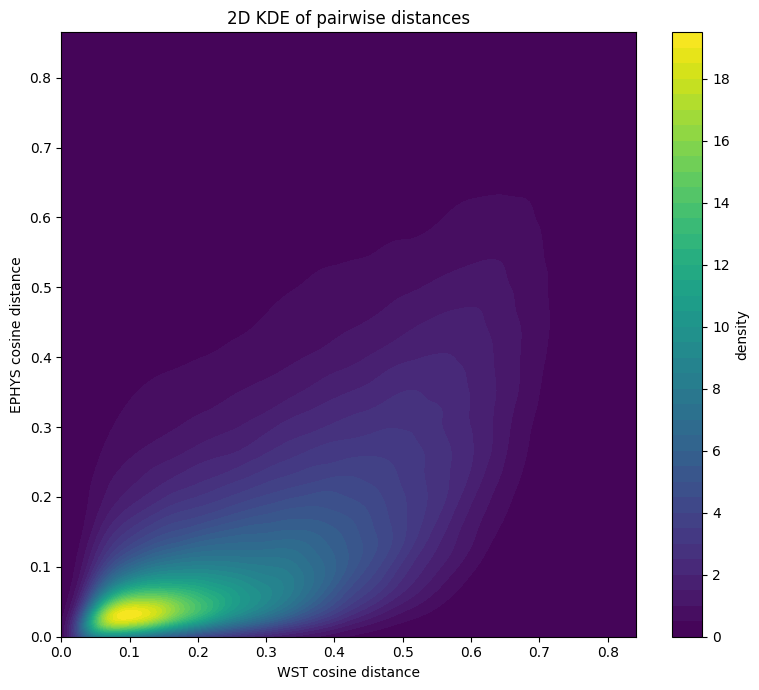

In [5]:
plt.figure(figsize=(8, 7))
plt.contourf(xx, yy, zz, levels=40, cmap="viridis")
plt.colorbar(label="density")

plt.xlabel("WST cosine distance")
plt.ylabel("EPHYS cosine distance")
plt.title("2D KDE of pairwise distances")
plt.tight_layout()
plt.show()


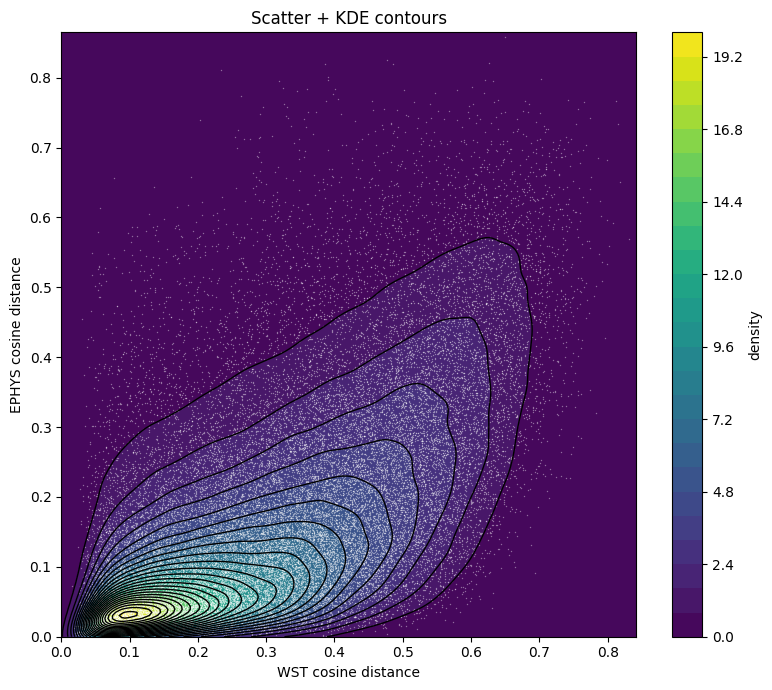

In [21]:
rng = np.random.default_rng(0)
idx = rng.choice(len(dx), size=40000, replace=False)

plt.figure(figsize=(8, 7))

cf = plt.contourf(xx, yy, zz, levels=30, cmap="viridis")
plt.colorbar(cf, label="density")

plt.contour(xx, yy, zz, levels=30, colors="black", linewidths=1)

plt.scatter(
    dx[idx], dy[idx],
    s=1, c="white", alpha=0.4, linewidths=0
)

plt.xlabel("WST cosine distance")
plt.ylabel("EPHYS cosine distance")
plt.title("Scatter + KDE contours")

plt.tight_layout()
plt.show()



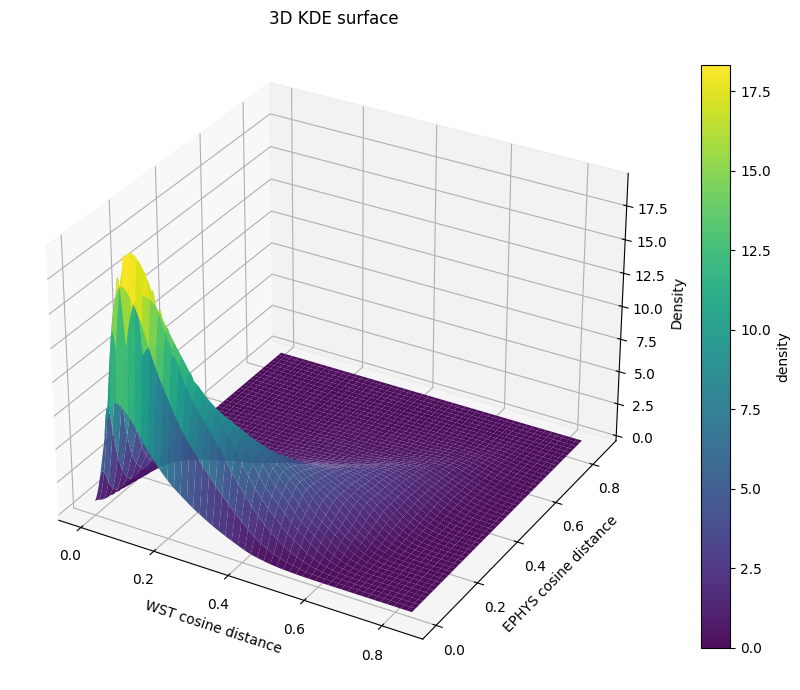

In [16]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    xx, yy, zz,
    cmap = "viridis",
    linewidth=0,
    antialiased=True,
    alpha=0.95
)

ax.set_xlabel("WST cosine distance")
ax.set_ylabel("EPHYS cosine distance")
ax.set_zlabel("Density")
ax.set_title("3D KDE surface")

fig.colorbar(surf, ax=ax, shrink=0.9, label="density")
plt.tight_layout()
plt.show()


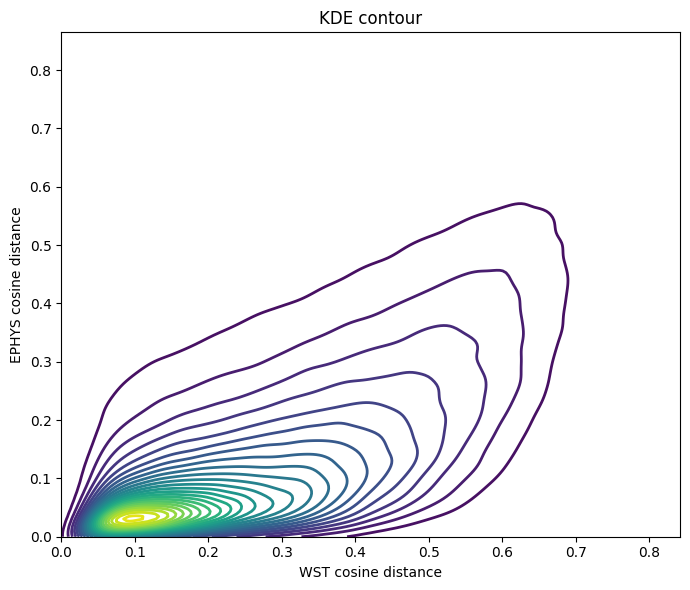

In [25]:
plt.figure(figsize=(7, 6))
plt.contour(xx, yy, zz, levels=30, cmap="viridis", linewidths=2)
plt.xlabel("WST cosine distance")
plt.ylabel("EPHYS cosine distance")
plt.title("KDE contour")
plt.tight_layout()
plt.show()
